# Notebook structure¶
This notebook is intended to provide a walkthrough to reproduce the main results reported in the paper "Describing Materials via Interpretable Machine Learning: The Example of Superconductivity". Within this notebook, we will:

1. Plot the dataset distribution.
2. Generate the violin plots associated with the Train and the Prediction errors associated with the models of Xie and the optimal model found after our cross-validation process.
3. Compare experimental $T_c$ against the values predicted by our optimal model (Fig. 3 in the paper).

## 1. Dataset distribution
The dataset considered in our studies contains 81 conventional superconductors. These materials were carefully selected by mapping the Supercon dataset of experimentally reported $T_c$ values onto structures available in the 3DSC$_{\text{MP}}$ for which electron-phonon parameters were available. The mean value of $T_c$ in the dataset is 4.30 K and the material with the highest $T_c$ is MgB$_2$ ($T_c=38$ K). Most of the data is located in the low temperature region. There is a notorious gap in the distribution between 17 and 38 K. This reflects the limited data availability of conventional superconductors within this temperature range and may limit the SISSO models to describe materials in this region. 

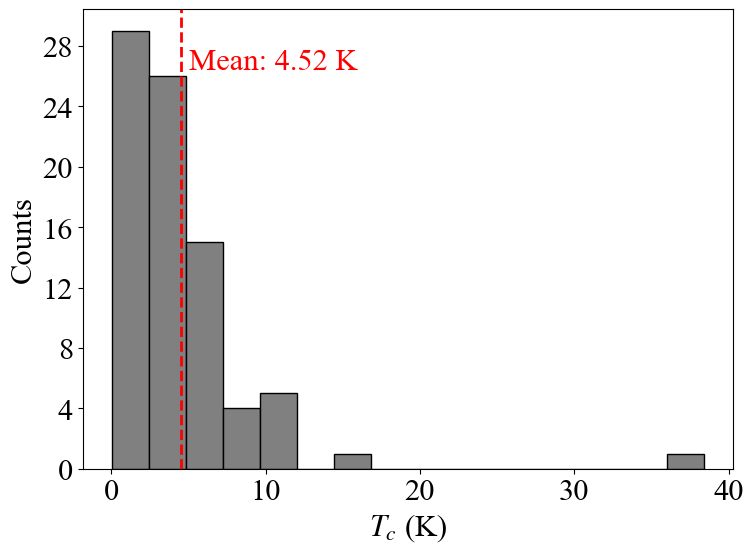

In [3]:
#import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Font setup
plt.rcParams.update({'font.size': 22})
plt.rcParams["font.family"] = "Times New Roman"
rc = {"mathtext.fontset": "stix"}
plt.rcParams.update(rc)

# Read dataset
df = pd.read_csv('../1_Dataset/data.csv')
tc_mean = df['Tc_exp (K)'].mean()

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Histogram
counts, bins = np.histogram(df['Tc_exp (K)'], bins=16)
width = (bins[1] - bins[0]) / 1.
ax.bar(bins[:-1], counts, width=width, align='edge', color='grey', edgecolor='black')

# Labels
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylabel('Counts')
ax.set_xlabel(r'$T_c$ (K)')

# Add mean line + annotation
ax.axvline(tc_mean, color='red', linestyle='--', linewidth=2, label=f"Mean = {tc_mean:.1f} K")
ax.text(tc_mean+6, counts.max()*0.9, f"Mean: {tc_mean:.2f} K", color='red', ha='center', va='bottom', fontsize=22)

# Show the plot 
plt.tight_layout()
plt.show()

## 2. Train and prediction errors

From our Leave-pone-out cross validation (LOOCV) results, the SISSO hyperparameters associated with the lower mean absolute error (MAE) are rung 2 ($q=2$), dimension 1 ($D=1$) and the parametrization of the addition operator. The table below summarizes the results from our LOOCV for $q=2$. 

| Parametrized operations | $D = 1$  | $D = 2$ |  $D = 3$ |  $D = 4$ |  $D = 5$ |  
|---|---|---| ---| ---| ---|
|  None           | 2.915     | 3.083    |  5.686   | 3.366  | 4.122  |
| $\phi_i+\phi_j$ | **2.913** | 4.042    |  4.006   | 3.925  | 3.740  |
| $\phi_i-\phi_j$ | 3.079     | 3.478    | 55.647   | 3.402  | 3.580  |
| $\exp(\phi_i)$  | 2.915     | 3160.849 | 3155.467 | 24.586 | 26.617 |
| $\phi_i*\phi_j$ | 3.376     | 7.899    | 3.291    | 8.099  | 8.375  |

Using the optimal hyperparameters, we train a model using the 81-material dataset. The expression of the model is:

$T_c^{\mathrm{SISSO}} = c_0 + c_1 * d_1$

with

$d_{1} = \>\dfrac{ \mathrm{PE}_{\mu} -1.23 }{ \rho-2.72 } + 47.16*\left[\left(\mathrm{PE}_{\overline{\sigma}}-0.48\right)\left(\lambda^4\omega_{\log}-0.036\right)\right]$

In the following cell, we will plot the distribution of the absolute train and prediction errors for the model performance and compare it against a previous SISSO model proposed by Xie et al. (Eq. 2 of the paper). The box and violin plots show these distributions errors associated to both SISSO models:


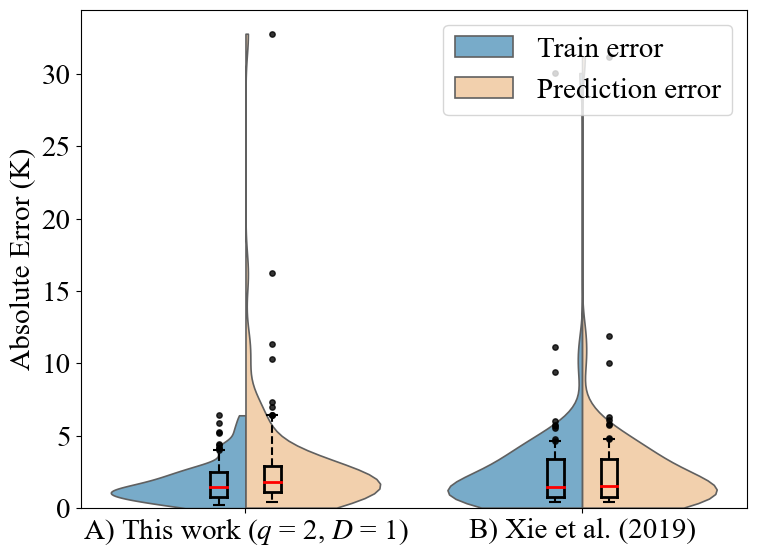

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df_train = pd.read_csv('plotting_data/train_errors.csv')
df_pred  = pd.read_csv('plotting_data/prediction_errors.csv')

# Font
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams.update({'font.size': 21})

# Prepare the data 
train_A = df_train['error_xie'].dropna()
train_B = df_train['error_optimal'].dropna()

test_A = df_pred['error_xie'][:].dropna()
test_B = df_pred['error_optimal'][:].dropna()

# Remove negative values
train_A = train_A[train_A >= 0]
train_B = train_B[train_B >= 0]
test_A = test_A[test_A >= 0]
test_B = test_B[test_B >= 0]

# Create melted DataFrame for seaborn split violin
model_labels = ['B) Xie et al. (2019)', 'A) This work ($q$ = 2, $D$ = 1)']
train_data = pd.DataFrame({
    'Model': [model_labels[0]] * len(train_A) + [model_labels[1]] * len(train_B),
    'Error': pd.concat([train_A, train_B], ignore_index=True),
    'Set': ['Train error'] * len(train_A) + ['Train error'] * len(train_B)
})
test_data = pd.DataFrame({
    'Model': [model_labels[0]] * len(test_A) + [model_labels[1]] * len(test_B),
    'Error': pd.concat([test_A, test_B], ignore_index=True),
    'Set': ['Prediction error'] * len(test_A) + ['Prediction error'] * len(test_B)
})
df_plot = pd.concat([train_data, test_data], ignore_index=True)

# Color selection
palette = sns.color_palette("tab20c")
custom_colors = [palette[1], palette[7]]

# Plot setup
plt.figure(figsize=(8, 6))
ax = sns.violinplot(data=df_plot, x='Model', y='Error', hue='Set', density_norm='width',bw_adjust=0.8,
                    split=True, inner=None, linewidth=1.2, palette=custom_colors, cut=0,order=model_labels[::-1])

# List of index ranges 
selected_indices = list(range(74, 81)) + list(range(155, 162)) + list(range(236, 243)) + list(range(317, 324))

# Function to extract top N% values
def get_top_percentile(data, percentile=90):
    cutoff = np.percentile(data, percentile)
    return data[data >= cutoff]

# Extract actual outlier values (top 10%)
train_A_outliers = get_top_percentile(train_A)
test_A_outliers = get_top_percentile(test_A)
train_B_outliers = get_top_percentile(train_B)
test_B_outliers = get_top_percentile(test_B)

# Set horizontal offsets to match violin sides
x_offsets = {'train_A': 1 - 0.08, 'test_A': 1 + 0.08,'train_B': 0 - 0.08,'test_B': 0 + 0.08,}

# Plot the outliers manually using scatter
plt.scatter([x_offsets['train_A']] * len(train_A_outliers), train_A_outliers,
            color='black', s=15, alpha=0.8, label='Top 10%' )
plt.scatter([x_offsets['test_A']] * len(test_A_outliers), test_A_outliers,
            color='black', s=15, alpha=0.8)
plt.scatter([x_offsets['train_B']] * len(train_B_outliers), train_B_outliers,
            color='black', s=15, alpha=0.8)
plt.scatter([x_offsets['test_B']] * len(test_B_outliers), test_B_outliers,
            color='black', s=15, alpha=0.8)

# Overlay percentiles manually for each half of the violin
def draw_percentiles(data, xpos, offset, color='black'):
    if len(data) < 5:
        return  # Skip if insufficient data
    p10, p25, p50, p75, p90 = np.percentile(data, [10, 25, 50, 75, 90])

    # Box (25–75)
    plt.plot([xpos + offset - 0.025, xpos + offset + 0.025], [p25, p25], color=color, linewidth=2)
    plt.plot([xpos + offset - 0.025, xpos + offset + 0.025], [p75, p75], color=color, linewidth=2)
    plt.plot([xpos + offset - 0.025, xpos + offset - 0.025], [p25, p75], color=color, linewidth=2)
    plt.plot([xpos + offset + 0.025, xpos + offset + 0.025], [p25, p75], color=color, linewidth=2)

    # Median
    plt.plot([xpos + offset - 0.025, xpos + offset + 0.025], [p50, p50], color='red', linewidth=2)

    # Whiskers
    plt.plot([xpos + offset, xpos + offset], [p75, p90], color=color, linestyle='--', linewidth=1.5)
    plt.plot([xpos + offset, xpos + offset], [p25, p10], color=color, linestyle='--', linewidth=1.5)
    plt.scatter([xpos + offset], [p90], color=color, marker='_', s=80)
    plt.scatter([xpos + offset], [p10], color=color, marker='_', s=80)

# Draw percentile overlays per violin half
draw_percentiles(train_A, xpos=1, offset=-0.08)
draw_percentiles(test_A, xpos=1, offset=+0.08)
draw_percentiles(train_B, xpos=0, offset=-0.08)
draw_percentiles(test_B, xpos=0, offset=+0.08)

# Labels and legend
ax.set_ylabel("Absolute Error (K)")
ax.set_xlabel("")
ax.set_ylim(bottom=0)
# Remove legend entries added by stripplot (which are duplicates)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="", loc='upper right')  # Only keep first two

# Display
plt.tight_layout()

The prediction errors come from the absolute errors observed in the 81 datapoints during the LOOCV scheme. The width of the violins reflects the number of systems associated to a specific error. The median and 90%-ile of the absolute train error distribution are 1.44 and 4.04 K, respectively, indicating the good quality of the fit. The median and 90%-ile of the absolute prediction error distribution are equal to 1.81 and 6.44 K. Thus, the prediction errors are only slightly higher than the train errors. In spite of the good overall predictive performance, the prediction errors associated to some materials are relatively high. For instance, the materials MgB$_2$, Se$_2$Ta,  Nb$_3$Sn,  S$_2$Ta, C$_2$I$_2$Y$_2$, are associated to prediction errors of 32.77, 16.21, 11.36, 10.31, 7.32 K, respectively. This indicates that these data points contain important information for modelling $T_c$.

For the comparisson witht the SISSO model of Xie et al. we refitted the 0.0953 coefficient in their within the same LOOCV scheme used for our model. Thus, at each iteration, the coefficient was optimized using the 80 training materials and the resulting model was evaluated on the left-out material. This procedure was repeated for all 81 materials. In addition, the coefficient was refitted using the complete dataset to obtain a model trained on all 81 materials, for which the corresponding train errors were calculated. The median and 90\%-ile of the absolute train error distribution associated to Xie's model are 1.50 and 4.80 K, respectively. The median and 90\%-ile of the absolute prediction error in our model's distribution are equal to 1.44 and 4.04 K. The prediction performance of our SISSO model is comparable to that of Xie, while showing a lower error on the available data. This difference may be associated with the broader range of primary features considered in our approach and the larger dataset used in the analysis.

## 3. $T_c^{\mathrm{SISSO}}$ model plot

As presented above, the expression of the model is:

$T_c^{\mathrm{SISSO}} = c_0 + c_1 * d_1$

with

$d_{1} = \>\dfrac{ \mathrm{PE}_{\mu} -1.23 }{ \rho-2.72 } + 47.16*\left[\left(\mathrm{PE}_{\overline{\sigma}}-0.48\right)\left(\lambda^4\omega_{\log}-0.036\right)\right]$

This model contains two constants $c_0$, and $c_1$ with values 2.31 K, and 4.67 K g cm$^{-3}$, respectively. This model has one descriptor component $d_1$ with units of g$^{-1}$ cm$^{3}$ that depends on 5 primary features: the mean and weighted standard deviation of the Pauling electronegativity $\mathrm{PE}_{\mu}$ and $\mathrm{PE}_{\overline{\sigma}}$, the compound density $\rho$, and the electron-phonon parameters $\lambda$ and $\omega_{\log}$ given by the term $\lambda^4\omega_{\log}$.

In the upcomming cell, we are going to plot $T_c$ ($y$-axis) against the values for the descriptor ($x$-axis) found by our model SISSO studies. The dashed line indicates the prediction of our model, $T_c^{\mathrm{SISSO}}$. The lower the value of the descriptor (more negative), the higher the predicted $T_c$. All points in this figure correspond to the experimentally determined values of $T_c$ with the blue circles indicating the materials in the training dataset. Most of the materials are located on the bottom-right portion of the plot. This region is associated to low, close-to-zero $T_c$ values. The MgB$_2$ material has the most negative $d_1$ in the training data and therefore the higher $T_c$. Finally, the orange and green circles correspond to conventional and nonconventional superconductors, respectively, which were not used to train the model.

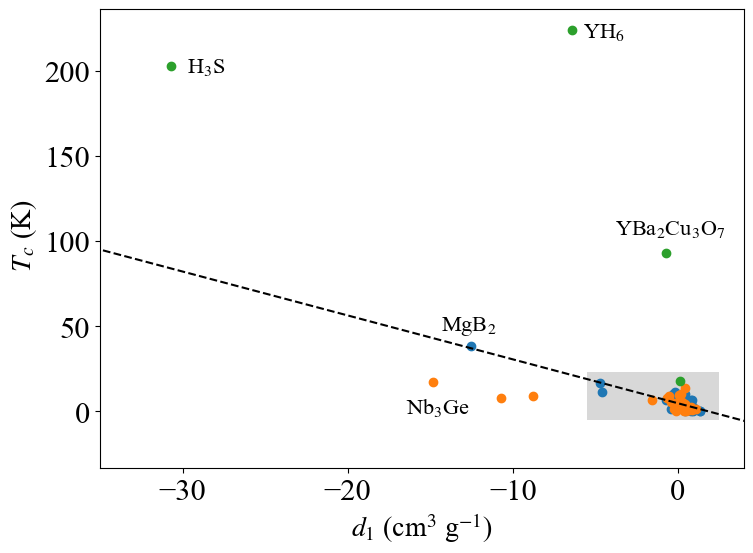

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams.update({'font.size': 22})

training     = pd.read_csv('plotting_data/training_data.csv')
conventional = pd.read_csv('plotting_data/validation_conventional.csv')
high_tc      = pd.read_csv('plotting_data/validation_high_Tc.csv')

# Create a mesh grid
X = np.linspace(-40, 10, 500)
c0 = 4.670473021268798e+00
c1 = -2.578932259921570e+00

# Define a function for the Z-values
model = c0 + c1*X 

# Retrive data for the plot
d1_train = training['d1'].to_list()          # d1 values from the training data
Tc_train = training['Tc_exp (K)'].to_list()  # Tc for the training materials
d1_conv  = conventional['d1'].to_list()      # d1 values for the vaidation set of conventional superconductors
d1_high  = high_tc['d1'].to_list()           # d1 values for the vaidation set of high Tc materials
Tc_conv  = conventional['Tc_exp (K)'].to_list()  # Tc for the vaidation set of conventional superconductors
Tc_high  = high_tc['Tc_exp (K)'].to_list()       # Tc for the vaidation set of high Tc materials

# Set up the plots
plt.figure(figsize=(8, 6))
plt.scatter(d1_train, Tc_train, marker ='o', label="Training")
plt.scatter(d1_conv, Tc_conv, marker ='o', label="Conventional")
plt.scatter(d1_high, Tc_high, marker ='o', label="Non-conventional")
plt.plot(X, model, color='black', linestyle="--")

# Labels and title
plt.xlabel('$d_1$ (cm$^3$ g$^{-1}$)', fontsize=20)
plt.ylabel('$\>\>T_c$ (K)', fontsize=20)
plt.xlim(-35,4)

# Add the gray rectangle
plt.gca().add_patch(
    Rectangle( (-5.5, -5), 8, 28, facecolor='gray', edgecolor='none',
    alpha=0.3, zorder=0) )

# Validation materials labels
plt.text(0.53, 0.30, "MgB$_2$",
         transform=plt.gca().transAxes,
         fontsize=16, color='Black')
plt.text(0.135, 0.863, "H$_3$S",
         transform=plt.gca().transAxes,
         fontsize=16, color='black')
plt.text(0.475, 0.12, "Nb$_3$Ge",
         transform=plt.gca().transAxes,
         fontsize=16, color='black')
plt.text(0.75, 0.94, "YH$_6$",
         transform=plt.gca().transAxes,
         fontsize=16, color='black')
plt.text(0.8, 0.51, "YBa$_2$Cu$_3$O$_7$",
         transform=plt.gca().transAxes,
         fontsize=16, color='black')

# Display
plt.tight_layout()
plt.show()

To assess the generalizability of the $T_c^{\mathrm{SISSO}}$ model, we used our model and the one from Xie to predict the $T_c$ of 32 superconductor materials that were not included in the training set. The predicted $T_c$ values for these validation materials can be seen in Table 3 of the paper. Here we only summarize the MAE values for these sets. In general, our model shows a lower MAE (4.63 K) for the 28 conventional superconductors compare to the model of Xie (5.05 K). However, the associated errors to the non-conventional superconductors are in the range [13, 215 K]. In spite of this overall insufficient performance, the SISSO model correctly indicates that H$_3$S presents one of the highest $T_c$ among all the materials analyzed in this paper (203 K). This indicates that, although the model fails quantitatively for nonconventional superconductors, it can preserve qualitative ranking trends